<a href="https://colab.research.google.com/github/anuragjaine/credit-risk-modelling/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm

print("All libraries already available in Colab")
print(f"Pandas version: {pd.__version__}")

All libraries already available in Colab
Pandas version: 2.2.2


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

drive_path = "/content/drive/MyDrive/credit-risk-modelling"
print("Contents of credit-risk-modelling folder:")
print(os.listdir(drive_path))

Contents of credit-risk-modelling folder:
['data']


In [6]:
print(os.listdir(drive_path + "/data/raw"))

['accepted_2007_to_2018Q4.csv.gz']


# Notebook 01: Data Understanding

## Objectives
1. Load the LendingClub dataset
2. Understand the shape and structure of data
3. Identify the target variable (loan_status)
4. Check class balance (Default vs Non-Default)
5. Identify potential data leakage variables

## Business Question
Can we predict which loan applicants are likely to default
using only the information available at the time of loan application?

## Dataset
- Source: LendingClub Loan Data (2007 - 2018)
- File: accepted_2007_to_2018Q4.csv.gz
- Approx. 2.2 million loans

In [7]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 2.2.2


In [8]:
# File path in Google Drive
file_path = "/content/drive/MyDrive/credit-risk-modelling/data/raw/accepted_2007_to_2018Q4.csv.gz"

# Load dataset (may take 2-4 minutes)
print("Loading dataset... please wait")
df = pd.read_csv(file_path, compression='gzip', low_memory=False)
print(f"Dataset loaded successfully")
print(f"Shape: {df.shape}")

Loading dataset... please wait
Dataset loaded successfully
Shape: (2260701, 151)


In [9]:
# Check shape and memory
print(f"Number of rows (loans):    {df.shape[0]:,}")
print(f"Number of columns:         {df.shape[1]}")
print(f"Memory usage:              {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Number of rows (loans):    2,260,701
Number of columns:         151
Memory usage:              5992.29 MB


In [10]:
# View first 5 rows
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [11]:
# List all column names
print(f"Total columns: {len(df.columns)}\n")
for i, col in enumerate(df.columns):
    print(f"{i+1:3d}. {col}")

Total columns: 151

  1. id
  2. member_id
  3. loan_amnt
  4. funded_amnt
  5. funded_amnt_inv
  6. term
  7. int_rate
  8. installment
  9. grade
 10. sub_grade
 11. emp_title
 12. emp_length
 13. home_ownership
 14. annual_inc
 15. verification_status
 16. issue_d
 17. loan_status
 18. pymnt_plan
 19. url
 20. desc
 21. purpose
 22. title
 23. zip_code
 24. addr_state
 25. dti
 26. delinq_2yrs
 27. earliest_cr_line
 28. fico_range_low
 29. fico_range_high
 30. inq_last_6mths
 31. mths_since_last_delinq
 32. mths_since_last_record
 33. open_acc
 34. pub_rec
 35. revol_bal
 36. revol_util
 37. total_acc
 38. initial_list_status
 39. out_prncp
 40. out_prncp_inv
 41. total_pymnt
 42. total_pymnt_inv
 43. total_rec_prncp
 44. total_rec_int
 45. total_rec_late_fee
 46. recoveries
 47. collection_recovery_fee
 48. last_pymnt_d
 49. last_pymnt_amnt
 50. next_pymnt_d
 51. last_credit_pull_d
 52. last_fico_range_high
 53. last_fico_range_low
 54. collections_12_mths_ex_med
 55. mths_since_la

In [12]:
# Check unique values in loan_status
print("Unique values in loan_status:\n")
status_counts = df['loan_status'].value_counts()
print(status_counts)
print(f"\nTotal records: {df['loan_status'].count():,}")

Unique values in loan_status:

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Total records: 2,260,668


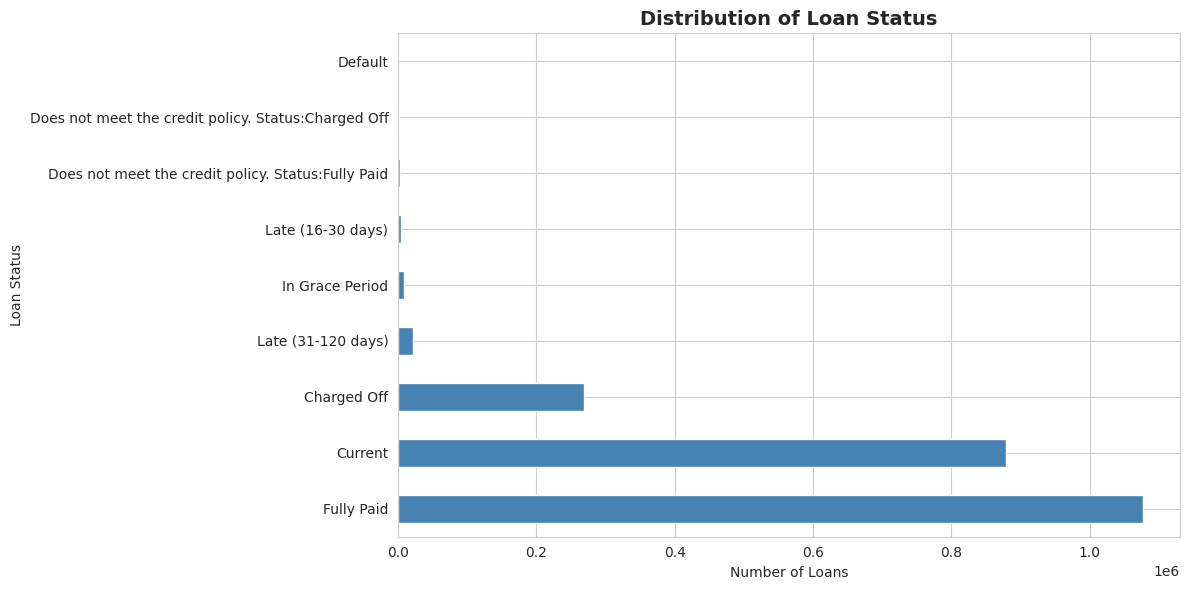


Percentage breakdown:
loan_status
Fully Paid                                             47.63
Current                                                38.85
Charged Off                                            11.88
Late (31-120 days)                                      0.95
In Grace Period                                         0.37
Late (16-30 days)                                       0.19
Does not meet the credit policy. Status:Fully Paid      0.09
Does not meet the credit policy. Status:Charged Off     0.03
Default                                                 0.00
Name: count, dtype: float64


In [13]:
# Plot loan status distribution
plt.figure(figsize=(12, 6))
status_counts.plot(kind='barh', color='steelblue')
plt.title('Distribution of Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Number of Loans')
plt.ylabel('Loan Status')
plt.tight_layout()
plt.show()

# Show percentages
print("\nPercentage breakdown:")
print((status_counts / len(df) * 100).round(2))

## Understanding loan_status Categories

| Status | Meaning | Use in Modelling |
|---|---|---|
| Fully Paid | Loan fully repaid | Non-Default (0) ✅ |
| Charged Off | Loan written off as loss | Default (1) ✅ |
| Default | Officially in default | Default (1) ✅ |
| Late (31-120 days) | Borrower very late | Uncertain - exclude |
| Late (16-30 days) | Slightly late | Uncertain - exclude |
| In Grace Period | Recently late | Uncertain - exclude |
| Current | Loan still ongoing | Outcome unknown - exclude |
| Does not meet credit policy | Old policy loans | Exclude |

We will keep only **Fully Paid** and **Charged Off** for binary classification.
This gives us clean, definitive outcomes for modelling.

In [16]:
# Convert issue_d to datetime format
# Format example: "Dec-2015" so we use format='%b-%Y'
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

# Check date range
print("Earliest loan issue date:", df['issue_d'].min())
print("Latest loan issue date:  ", df['issue_d'].max())
print("\nNumber of missing dates:", df['issue_d'].isnull().sum())
print("\nSample of issue_d values:")
print(df['issue_d'].head(10))

Earliest loan issue date: 2007-06-01 00:00:00
Latest loan issue date:   2018-12-01 00:00:00

Number of missing dates: 33

Sample of issue_d values:
0   2015-12-01
1   2015-12-01
2   2015-12-01
3   2015-12-01
4   2015-12-01
5   2015-12-01
6   2015-12-01
7   2015-12-01
8   2015-12-01
9   2015-12-01
Name: issue_d, dtype: datetime64[ns]


In [17]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Top 30 columns with most missing values
print("Top 30 columns with most missing values:\n")
print(missing_summary.head(30))

Top 30 columns with most missing values:

                                            Missing Count  Missing %
member_id                                         2260701     100.00
orig_projected_additional_accrued_interest        2252050      99.62
hardship_reason                                   2249784      99.52
hardship_payoff_balance_amount                    2249784      99.52
hardship_last_payment_amount                      2249784      99.52
payment_plan_start_date                           2249784      99.52
hardship_type                                     2249784      99.52
hardship_status                                   2249784      99.52
hardship_start_date                               2249784      99.52
deferral_term                                     2249784      99.52
hardship_amount                                   2249784      99.52
hardship_dpd                                      2249784      99.52
hardship_loan_status                              2249784    

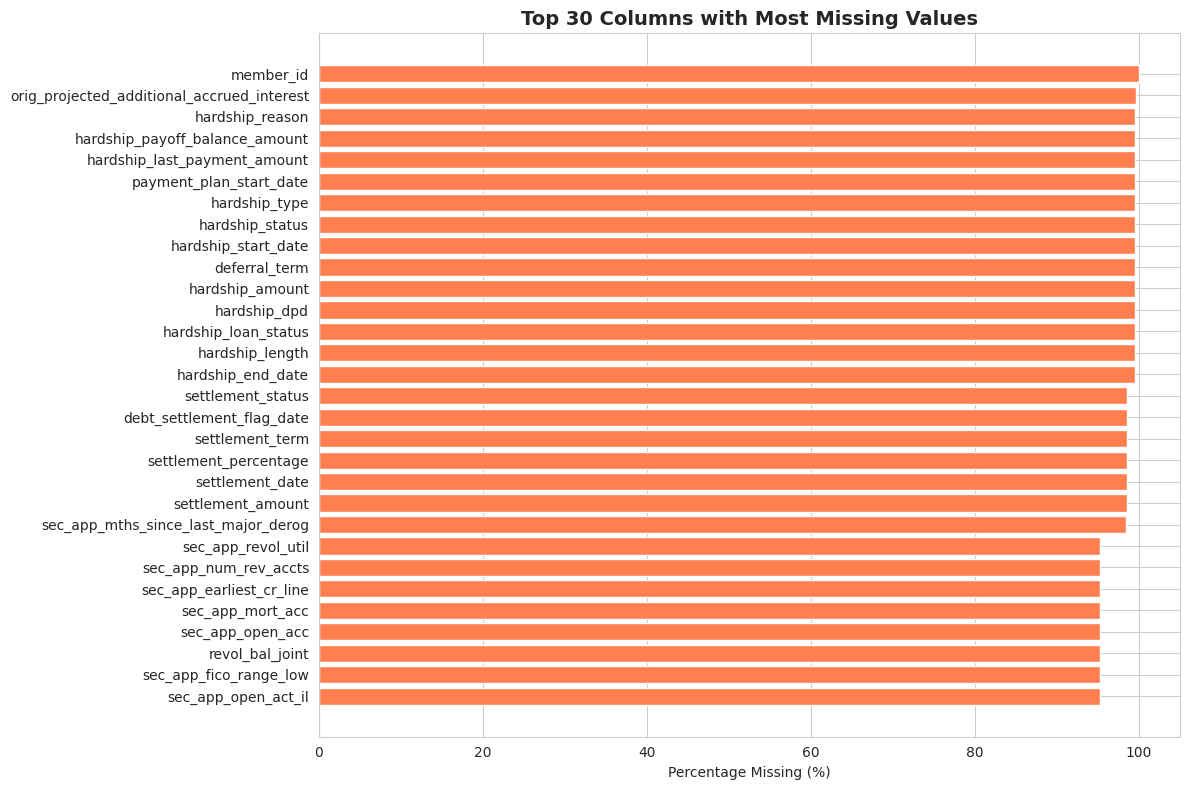

In [18]:
# Plot missing data
plt.figure(figsize=(12, 8))
top_missing = missing_summary.head(30)
plt.barh(top_missing.index, top_missing['Missing %'], color='coral')
plt.xlabel('Percentage Missing (%)')
plt.title('Top 30 Columns with Most Missing Values', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Initial Observations

1. The dataset has approximately 2.26 million loan records across 151 columns
2. The target variable is `loan_status` with multiple categories
3. About 46% of loans are **Fully Paid** (non-default)
4. About 12% are **Charged Off** (default)
5. About 40% are **Current** (still ongoing - we exclude these)
6. Many columns have very high missing values (>90%)
7. Date range covers October 2007 to December 2018

## Decisions for Next Notebook
- Keep only "Fully Paid" and "Charged Off" loans
- Drop columns with >50% missing values
- Identify and remove data leakage columns
- Define target variable: 1 = Charged Off, 0 = Fully Paid

## Next Steps (Notebook 02)
- Filter dataset to relevant loan statuses
- Remove leakage variables
- Define binary target variable
- Perform detailed Exploratory Data Analysis
